# 🚀 EDA Final Summary

From analysis we conclude:

## 📌 1. Demand is highly time-dependent
- Morning and evening peaks

## 📌 2. Demand is highly zone-dependent
- Few zones dominate trips

## 📌 3. Revenue is skewed
- Most trips low fare, few high value

## 📌 4. Strong spatial + temporal interaction
- Zone + time together defines demand

---

# 🎯 FINAL IMPACT ON FEATURE ENGINEERING

Based on EDA, we will create:

✔ Hour feature (critical)  
✔ Zone feature (critical)  
✔ Peak hour flag  
✔ Demand aggregation per zone-hour  
✔ Avg fare per zone  
✔ Rolling demand features  

# 🎯 Features we will build next:

Based on EDA, we will create:

## 📍 Spatial Features
- PULocationID

## ⏰ Time Features
- hour
- day_of_week
- peak_hour_flag

## 📊 Demand Features
- trips per zone-hour

## 💰 Revenue Features
- avg fare per zone

## ⚖ Interaction Features
- zone + time demand

---

# 🚖 NYC Taxi Demand System

## Notebook 2: Exploratory Data Analysis (EDA)

### Objective
Understand demand, revenue, and spatial patterns in NYC taxi data to guide feature engineering and model building.

### Outcome
We will identify:
- High-demand zones
- Peak time periods
- Revenue patterns
- Outliers and data issues

These insights will directly decide ML features.

## 🎯 Why EDA?

Before building any model, we must understand:

- Where demand happens
- When demand happens
- How revenue varies
- What patterns exist in the data

EDA ensures:
✔ We don’t create random features  
✔ We build meaningful ML signals  
✔ Our model reflects real-world behavior  

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet("/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/Usecase4_Driver_Positioning_System/data/yellow_tripdata_2026-01.parquet")

df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


In [4]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3724889 entries, 0 to 3724888
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1088058
trip_distance                  0
RatecodeID               1088058
store_and_fwd_flag       1088058
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     1088058
Airport_fee              1088058
cbd_congestion_fee             0
dtype: int64

In [21]:
df.dropna()

,VendorID,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,hour,day_of_week
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,...,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00,0,3
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,...,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75,0,3
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,...,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75,0,3
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,...,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75,0,3
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,...,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2636826,1,2026-01-31 23:52:51,2026-02-01 00:08:38,1.0,0.00,1.0,N,249,142,1,...,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75,23,5
2636827,2,2026-01-31 23:19:40,2026-01-31 23:30:21,1.0,1.86,1.0,N,230,239,1,...,0.5,3.21,0.0,1.0,21.06,2.5,0.0,0.75,23,5
2636828,2,2026-01-31 23:31:52,2026-01-31 23:46:55,1.0,2.66,1.0,N,239,262,1,...,0.5,5.32,0.0,1.0,26.62,2.5,0.0,0.00,23,5
2636829,2,2026-01-31 23:30:25,2026-01-31 23:34:10,4.0,0.36,1.0,N,170,170,1,...,0.5,1.00,0.0,1.0,12.55,2.5,0.0,0.75,23,5


In [22]:
df.describe()

,VendorID,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,hour,day_of_week
count,3.724889e+06,3724889,3724889,2.636831e+06,3.724889e+06,2.636831e+06,3.724889e+06,3.724889e+06,3.724889e+06,3.724889e+06,...,3.724889e+06,3.724889e+06,3.724889e+06,3.724889e+06,3.724889e+06,2.636831e+06,2.636831e+06,3.724889e+06,3.724889e+06,3.724889e+06
mean,1.873598e+00,2026-01-17 01:44:52.106518,2026-01-17 02:02:03.696138,1.256271e+00,6.455647e+00,5.218853e+00,1.614372e+02,1.609936e+02,8.465637e-01,2.080425e+01,...,4.833766e-01,2.608142e+00,4.983751e-01,9.479130e-01,2.917853e+01,2.154870e+00,1.482938e-01,5.196437e-01,1.411313e+01,3.136847e+00
min,1.000000e+00,2025-12-31 23:57:29,2025-12-31 23:57:32,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-2.555200e+03,...,-5.000000e-01,-8.888000e+01,-9.450000e+01,-1.000000e+00,-2.560200e+03,-2.500000e+00,-1.750000e+00,-7.500000e-01,0.000000e+00,0.000000e+00
25%,2.000000e+00,2026-01-09 17:51:59,2026-01-09 18:08:47,1.000000e+00,1.000000e+00,1.000000e+00,1.140000e+02,1.070000e+02,0.000000e+00,1.000000e+01,...,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.700000e+01,2.500000e+00,0.000000e+00,0.000000e+00,1.000000e+01,2.000000e+00
50%,2.000000e+00,2026-01-16 21:20:56,2026-01-16 21:36:14,1.000000e+00,1.810000e+00,1.000000e+00,1.610000e+02,1.620000e+02,1.000000e+00,1.560000e+01,...,5.000000e-01,2.000000e+00,0.000000e+00,1.000000e+00,2.305000e+01,2.500000e+00,0.000000e+00,7.500000e-01,1.500000e+01,3.000000e+00
75%,2.000000e+00,2026-01-24 07:25:11,2026-01-24 07:40:22,1.000000e+00,3.730000e+00,1.000000e+00,2.330000e+02,2.340000e+02,1.000000e+00,2.610000e+01,...,5.000000e-01,3.710000e+00,0.000000e+00,1.000000e+00,3.383000e+01,2.500000e+00,0.000000e+00,7.500000e-01,1.900000e+01,5.000000e+00
max,7.000000e+00,2026-02-01 00:45:01,2026-02-01 23:35:31,9.000000e+00,2.690975e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,2.555200e+03,...,4.750000e+00,7.660000e+02,1.222200e+02,1.000000e+00,2.560200e+03,2.500000e+00,2.675000e+01,7.500000e-01,2.300000e+01,6.000000e+00
std,7.014583e-01,NaN,NaN,6.702431e-01,6.488855e+02,1.965370e+01,6.706657e+01,7.103604e+01,7.120493e-01,1.892701e+01,...,1.145558e-01,3.917405e+00,2.131731e+00,2.654859e-01,2.258553e+01,9.423645e-01,5.336714e-01,3.568099e-01,5.984992e+00,1.831234e+00


In [34]:
df[df["fare_amount"] < 0].shape
df = df[df["fare_amount"] > 0]

### Why?

Taxi fare cannot be negative → these are data errors or system glitches.
So we remove them.

In [35]:
df = df[df["trip_distance"] > 0]

### Why?

Zero distance trips are invalid or logging errors.

In [36]:
df.duplicated().sum()
df = df.drop_duplicates()


## 📊 What we check here

- Fare distribution
- Trip distance range
- Outliers presence

This helps us detect data quality issues early.

In [23]:
df = df.rename(columns={
    "tpep_pickup_datetime": "pickup_datetime",
    "tpep_dropoff_datetime": "dropoff_datetime"
})

In [24]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])

df["hour"] = df["pickup_datetime"].dt.hour
df["day_of_week"] = df["pickup_datetime"].dt.dayofweek

### Why?

We need time features to analyze demand patterns:
- rush hours
- weekday behavior

6.1 Demand Distribution (Hourly)

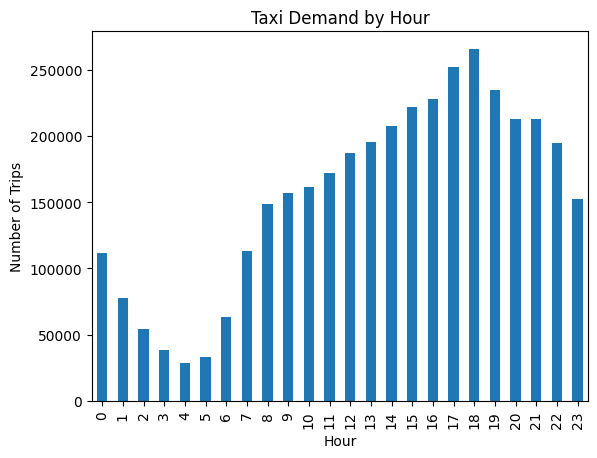

In [25]:
hourly_demand = df.groupby("hour").size()

plt.figure()
hourly_demand.plot(kind="bar")
plt.title("Taxi Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Trips")
plt.show()

## 📈 Insight: Hourly Demand Pattern

We observe:
- Peak demand during morning and evening hours
- Low demand during late night

👉 This directly defines:
- Peak hour feature
- Time-based weighting in model

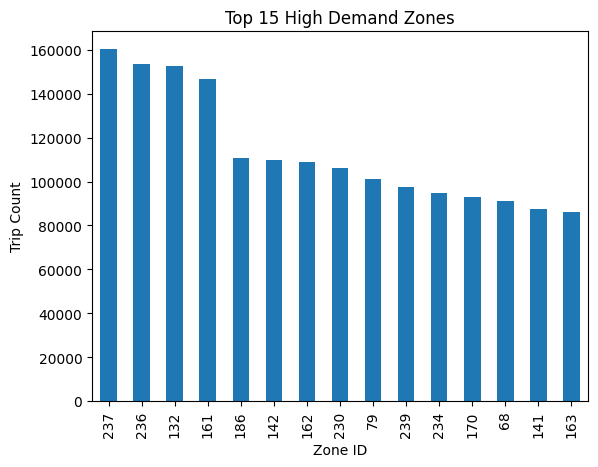

In [26]:
zone_demand = df["PULocationID"].value_counts().head(15)

plt.figure()
zone_demand.plot(kind="bar")
plt.title("Top 15 High Demand Zones")
plt.xlabel("Zone ID")
plt.ylabel("Trip Count")
plt.show()

## 📍 Insight: Spatial Demand

Some zones dominate trip volume.

👉 Conclusion:
- Demand is highly location-dependent
- Zone ID is a critical feature

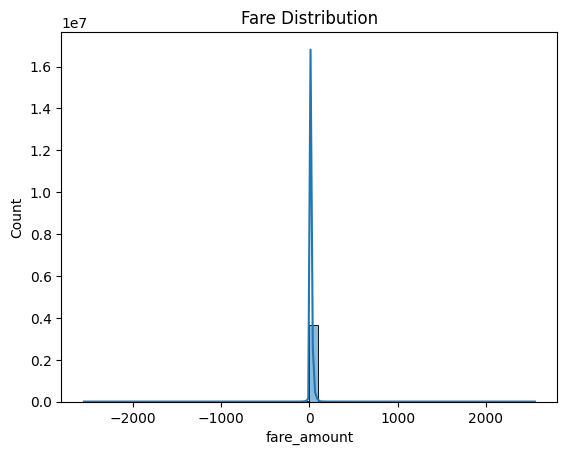

In [27]:
plt.figure()
sns.histplot(df["fare_amount"], bins=50, kde=True)
plt.title("Fare Distribution")
plt.show()

## 💰 Insight: Revenue Patterns

We observe:
- Most fares are in a low-mid range
- Few high-value trips exist

👉 This suggests:
- Revenue is skewed
- We may need log transformation or normalization later

. Bivariate Analysis

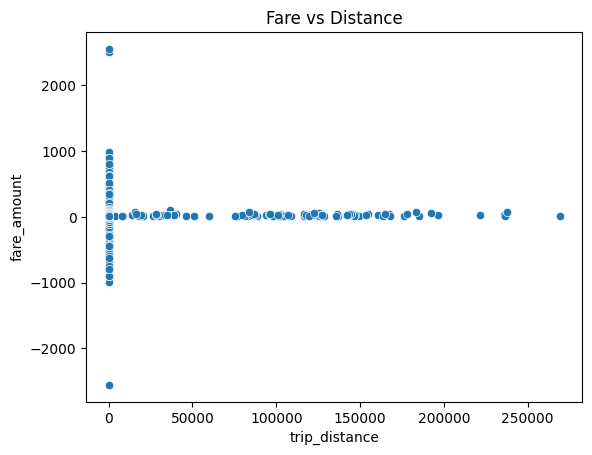

In [28]:
sns.scatterplot(x="trip_distance", y="fare_amount", data=df)
plt.title("Fare vs Distance")
plt.show()

## 📊 Insight: Fare-Distance Relationship

We expect:
- Positive correlation between distance and fare
- Outliers indicate anomalies or surge pricing

👉 This helps validate data quality

In [15]:
peak_data = df.groupby(["PULocationID", "hour"]).size().reset_index(name="demand")

peak_data.sort_values("demand", ascending=False).head()

,PULocationID,hour,demand
3513,161,18,13493
5178,236,15,13280
3512,161,17,13053
5204,237,17,12758
5202,237,15,12654


##  Insight: Spatio-Temporal Demand

Demand is not static:
- Certain zones peak at certain hours
- Demand is dynamic across time + location

👉 This is the core of your ML model design

In [16]:
df["fare_amount"].describe()

count    3.724889e+06
mean     2.080425e+01
std      1.892701e+01
min     -2.555200e+03
25%      1.000000e+01
50%      1.560000e+01
75%      2.610000e+01
max      2.555200e+03
Name: fare_amount, dtype: float64

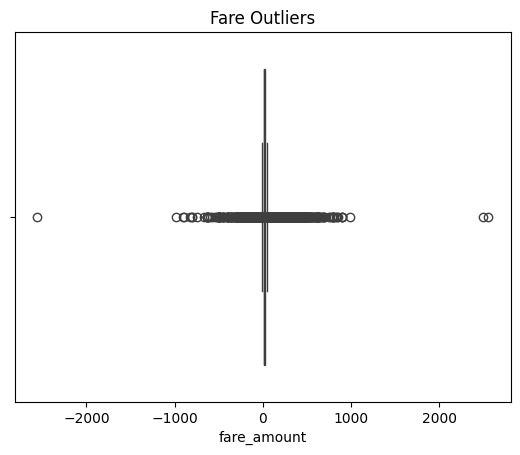

In [17]:
sns.boxplot(x=df["fare_amount"])
plt.title("Fare Outliers")
plt.show()

## 🚨 Outlier Insight

We detect extreme values in fare.

👉 Action:
- Remove or cap outliers in preprocessing
- Prevent model distortion

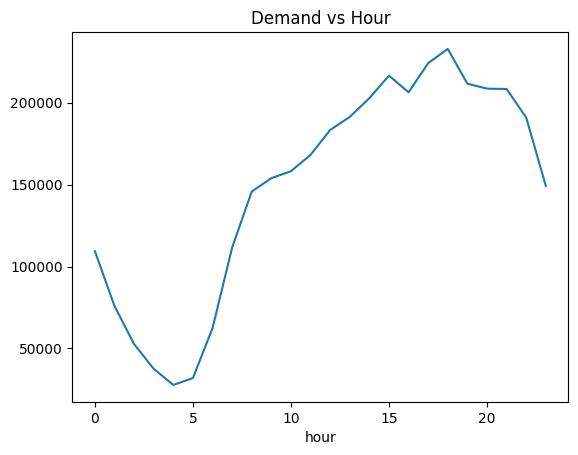

In [37]:
hour_zone = df.groupby("hour").size()

plt.figure()
hour_zone.plot()
plt.title("Demand vs Hour")
plt.show()

### Insight:
Shows peak demand cycles → crucial for feature engineering.

#  EDA INSIGHTS SUMMARY

## 1. Demand Patterns
- Strong variation across hours
- Peak during morning & evening

## 2. Spatial Patterns
- Few zones dominate demand

## 3. Revenue Patterns
- Fare is skewed (few high-value trips)

## 4. Relationships
- Strong correlation between distance and fare

## 5. Data Quality
- Some invalid values removed (negative fares, zero distance)

# 🎯 Features we will build next:

Based on EDA, we will create:

## 📍 Spatial Features
- PULocationID

## ⏰ Time Features
- hour
- day_of_week
- peak_hour_flag

## 📊 Demand Features
- trips per zone-hour

## 💰 Revenue Features
- avg fare per zone

## ⚖ Interaction Features
- zone + time demand